In [44]:
from IPython.display import display, Latex
from IPython.core.display import HTML
%reset -f
%matplotlib inline
%autosave 300

import matplotlib.pyplot as plt
import numpy as np
from time import time

Autosaving every 300 seconds


# Un exemple convexe quadratique

On applique les différentes méthodes d'optimisation numérique vues en cours à un problème quadratique simple.

On veut résoudre numériquement le problème modèle suivant:
$$
(P) \qquad \inf \left\{ f(x):= \frac{1}{2} \left< A.x , x \right> - \left< b , x \right>
\, : \, x \in \mathbb{R}^3 \right\}
$$
où
$$
A := \begin{pmatrix}
1 & 4 & 3 \\
-3 & 6 & 3 \\
-1 & 0 & 7
\end{pmatrix}
\quad \quad et \quad \quad
b := \begin{pmatrix} -1 \\ 1 \\ -1 \end{pmatrix}.
$$


<b>1)</b> Montrer que $f$ est strictement convexe.
Ecrire les conditions d'optimalité et calculer la solution optimale théorique de $(P)$.

<i>Dans la suite, on pourra prendre comme test la distance à l'unique solution optimale de $(P)$.</i>


<span style="color:green">
    En posant $S=\frac{1}{2} (A+ A^T)$, on a
$$
\nabla f(x) = S.x - b \quad et \quad Hf(x) =S
$$
On remarque que $S$ est définie positive par de critère de Silvester,
et la solution optimale de $(P)$ est l'unique solution du système $S.x^* = b$.
    </span>

<b>2)</b> Programmer la méthode de la plus grande pente à pas constant pour ce problème.

On prendra pour point initial $x^0 = 0$ et pour précision $\varepsilon = 10^{-2}$ (pour tester) et $\varepsilon=10^{-6}$.

On testera diverses valeurs pour le pas choisi et on comparera la vitesse de convergence
(c'est-à-dire le nombre d'itérations nécessaires avant l'arrêt de l'algorithme).


In [45]:
A=np.array([[1,4,3],[-3,6,3],[-1,0,7]])
b=np.array([-1,1,-1])

def f(x):
    return .5*np.dot(A @ x,x) - np.dot(b,x)

print(f'A={A},\n A^T={A.T}\n f(0)={f(np.zeros(3))}')

A=[[ 1  4  3]
 [-3  6  3]
 [-1  0  7]],
 A^T=[[ 1 -3 -1]
 [ 4  6  0]
 [ 3  3  7]]
 f(0)=0.0


In [46]:
S=(A+A.T)/2

print(f'S={S}')

#calcul de la solution xstar

#xstar = np.linalg.inv(S) @ b 
xstar = np.linalg.solve(S,b)

print(f'la solution x^* est {xstar}')

S=[[1.  0.5 1. ]
 [0.5 6.  1.5]
 [1.  1.5 7. ]]
la solution x^* est [-1.08955224  0.26865672 -0.04477612]


In [47]:
x0=np.zeros(3)
print(f'x0={x0}')
eps=1.e-3
h=1.e-3

x=x0
while np.linalg.norm(S@x-b) > eps:
    x = x - h*(S@x-b)
    
print(x)

x0=[0. 0. 0.]
[-1.08835442  0.26859271 -0.04495453]


In [48]:
### initialisation
x0=np.zeros(3)
eps=1.e-9
h=2.e-1

gradf = lambda x : S @ x - b

### boucle principale
x=x0
cpt=0
debut=time()
# boucle de méthode du gradient
# x <- x(0) Tant que abs(x-xstar) > epsilon 
#comment calculer h ? 
# x <- x - h* nabla f(x)
#while np.linalg.norm(gradf(x)) > eps:
while np.linalg.norm(x-xstar) > eps:
    x = x - h*gradf(x)
    cpt +=1
temps=time()-debut
print(f'x={x}\n'+f'en {cpt} itérations et en {temps} sec.')

x=[-1.08955224  0.26865672 -0.04477612]
en 116 itérations et en 0.002359628677368164 sec.


On peut aussi faire un travail un peu plus poussé, en traçant la précision obtenue en fonction du nombre d'itérations effectuées. La théorie dit que la convergence est linéraire, donc en échelle semi-logarithmique on devrait observer une droite.

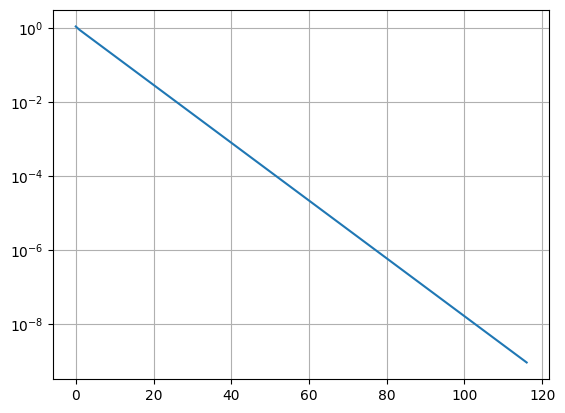

In [49]:
### initialisation
x0=np.zeros(3)
eps=1.e-9
h=2.e-1

gradf = lambda x : S @ x - b

### boucle principale
x=x0
cpt=0
iterations=[cpt]
dist=np.linalg.norm(x-xstar)
precision=[dist]
#while np.linalg.norm(gradf(x)) > eps:
while dist > eps:
    x = x - h*gradf(x)
    cpt +=1
    iterations.append(cpt)
    dist=np.linalg.norm(x-xstar)
    precision.append(dist)

plt.semilogy(iterations,precision)
plt.grid()

# on voit l evolution 
# au bout de 2000 iterations on est entre 10^0 et 10^-2 (plus de 10-2)
# tout les 1000 iterations, on divise par 100 
# pente est d environ -1

<b>3)</b> Programmer la méthode de la plus grande pente à pas optimal pour ce problème. Pour cela, on rappelle que la solution du problème
$$
\min\left\{ q(t) = f\left(x-t \nabla f(x)\right) \,:\, t > 0 \right\}
$$
est
$$
h_{opt} = \frac{\langle \nabla f(x), \nabla f (x) \rangle}{\langle A. \nabla f(x), \nabla f (x) \rangle}.
$$


In [50]:
# UTILISATION DU PAS OPTIMAL 
#seule différence : on fixe h a chaque etape
### initialisation
x0=np.zeros(3)
eps=1.e-9

gradf = lambda x : S @ x - b

### boucle principale
x=x0
cpt=0
debut=time()
#while np.linalg.norm(gradf(x)) > eps:
while np.linalg.norm(x-xstar) > eps:
    h=np.dot(gradf(x),gradf(x))/np.dot(A @ gradf(x),gradf(x))
    x = x - h*gradf(x)
    cpt +=1
temps=time()-debut
print(f'x={x}\n'+f'en {cpt} itérations et en {temps} sec.')

x=[-1.08955224  0.26865672 -0.04477612]
en 96 itérations et en 0.00525355339050293 sec.


On observe la convergence linéaire :

In [51]:
#TODO A REFAIRE

x0=np.zeros(3)
eps=1.e-9

gradf = lambda x : S @ x - b

### boucle principale
x=x0
cpt=0
debut=time()
while np.linalg.norm(x-xstar) > eps:
    h=np.dot(gradf(x),gradf(x))/np.dot(A @ gradf(x),gradf(x))
    x = x - h*gradf(x)
    cpt +=1
temps=time()-debut
print(f'x={x}\n'+f'en {cpt} itérations et en {temps} sec.')

x=[-1.08955224  0.26865672 -0.04477612]
en 96 itérations et en 0.004379987716674805 sec.


Remarque : on peut faire un code plus efficace pour le calcul du pas optimal 

In [52]:
#TODO A REFAIRE

x0=np.zeros(3)
eps=1.e-9

gradf = lambda x : S @ x - b

### boucle principale
x=x0
cpt=0
debut=time()
while np.linalg.norm(x-xstar) > eps:
    gdf = gradf(x)
    h=np.dot(gdf,gdf)/np.dot(A @ gdf,gdf)
    x = x - h*gdf
    cpt +=1
temps=time()-debut
print(f'x={x}\n'+f'en {cpt} itérations et en {temps} sec.')

x=[-1.08955224  0.26865672 -0.04477612]
en 96 itérations et en 0.0031332969665527344 sec.


<b>4)</b> Programmer la méthode de la plus grande pente en utilisant
la recherche linéaire avec critère d'Armijo pour calculer le pas
à chaque étape.

Faire plusieurs essais selon les valeurs des paramètres $\alpha$ et
$m_1$ de cette recherche linéaire et comparer les vitesses
de convergence (nombre d'itérations pour chaque recherche linéaire,
et pour l'algorithme dans son ensemble).

x=[-1.08955216  0.26865671 -0.04477613]
en 35 itérations et en 0.005802631378173828 sec.


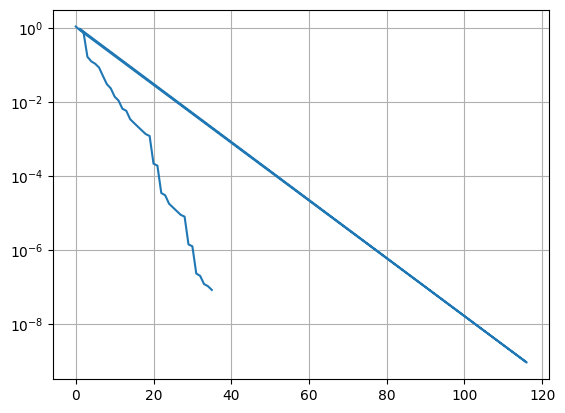

In [53]:
# Critère d armijo
x0=np.zeros(3)
eps=1.e-7
alpha = 2
m1 = 0.5

# q(0) = f(x)
# q'(0) = -abs(nabla*f(x))²
# 0 < m1 < 1

gradf = lambda x : S @ x - b
q = lambda t : f(x - t * gradf(x)) 

### boucle principale
x=x0
cpt=0
debut=time() 


while np.linalg.norm(x-xstar) > eps:
    gdf = gradf(x)
    q0 = q(0)
    q_prime_0 = -np.dot(gradf(x),gradf(x))
    # q_prime_0 = -np.linalg.norm(gradf(x))**2
    h = alpha
    while q(h) >= q0 + h*m1*q_prime_0:
        h = h/2
    x = x - h*gradf(x)
    cpt +=1
    iterations.append(cpt)
    dist = np.linalg.norm(x-xstar)
    precision.append(dist)
    
temps=time()-debut
print(f'x={x}\n'+f'en {cpt} itérations et en {temps} sec.')

plt.semilogy(iterations,precision)
plt.grid()

<b>5)</b> Programmer la méthode prox : on rappelle que cela consiste,
à l'étape $n$, à résoudre de manière approchée le problème
$$
\inf\left\{ f(x) + \frac{1}{2\,h_n} \| x-x^{(n)}\|^2 \,:\, x \in \mathbb{R}^3 \right\}
$$
et à choisir pour $x^{(n+1)}$ la solution approchée trouvée.

Pour résoudre le problème d'optimisation apparaissant à chaque itération on choisira une méthode à pas constant ou avec recherche linéaire.

In [ ]:
x0=np.zeros(3)
eps=1.e-7
h = 1

x = x0 
while np.linalg.norm(gradf(x)) > eps :
    x = 

<b>6)</b> Programmer la méthode de Newton pour ce problème.

In [54]:
## Initialisation

#x0=sol+0.1*np.random.rand(3,3)@sol  # on part d'un x0 proche de la solution
x0=np.zeros(3)
epsilon = 1e-7

print(sol, x0)

NameError: name 'sol' is not defined

<b>7)</b> Programmer la méthode de quasi-Newton BFGS pour ce problème, en employant une recherche linéaire avec le critère d'Armijo ou de Wolfe.

Pour la recherche linéaire de Wolfe, on utilise la fonction <b>line_search</b> de scipy.

# La fonction de Rosenbrock

Reprendre ce qui précède pour la fonction de Rosenbrock :
$$
f(x_1,x_2) = (x_2-x_1^2)^2+(x_1-1)^2
$$
On prendra différents points initiaux $x^0$ (par exemple $(0,0),\ldots$). 

1) On programme d'abord la méthode du gradient à pas constant :

2) On programme la méthode du gradient à pas optimal :

3) On programme la méthode d'Armijo.